In [1]:
import os, pickle, subprocess
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from py_util_dx.py_utils import setProjectPath
from visualizations import flatmap_real_vals 
import seaborn as sns
from scipy.stats import ttest_ind 
import Functional_Fusion.atlas_map as am
import nibabel as nib 
import pandas as pd 
import statsmodels.formula.api as smf

In [2]:
mpl.rcParams['font.family'] = 'helvetica'   # Global font family
mpl.rcParams['font.size'] = 12              # Global font size 
full_width = 8.5
half_width = full_width/2

In [3]:
dataset_name = 'IBC' # MDTB, Nishimoto, HCPur100, Language, Demand, IBC

projectPath, mainResultsPath = setProjectPath()
resultsPath = os.path.join(mainResultsPath, 'START_A2_gse_decomposition')
surface_helpers_dir = os.path.join(projectPath, 'surface_helpers')
PKL_output = os.path.join(resultsPath, dataset_name, f'{dataset_name}_output.pkl') 

In [4]:
with open(PKL_output, 'rb') as pf:
    output = pickle.load(pf)

## visualize voxel-wise $V_s/(V_s+V_g)$ for the whole cortex

In [5]:
result = output['whole_cortex']['voxel_wise']   # columns in the order: vg, vs, ve 
voxel_wise_cortex = np.divide(result[:, 1].reshape((-1, 1)), np.sum(result[:, 0:2], axis=1, keepdims=True)) 

In [6]:
print(np.nanmin(voxel_wise_cortex))
print(np.nanmax(voxel_wise_cortex)) 

-7200.418999469996
890257.4483557919


In [7]:
threshold_min = -0.5 
threshold_max = 1.5 
voxel_wise_cortex[voxel_wise_cortex>threshold_max] = threshold_max
voxel_wise_cortex[voxel_wise_cortex<threshold_min] = threshold_min

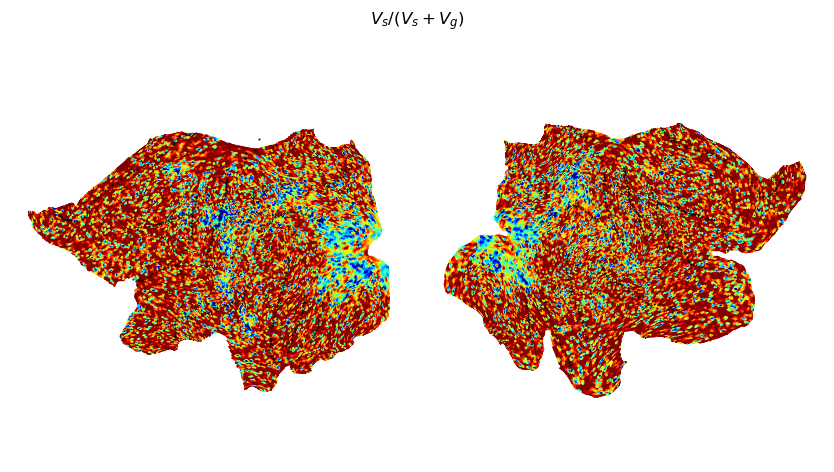

In [8]:
plt.figure().set_figwidth(full_width) 
plt.subplot(1, 2, 1)
flatmap_real_vals(voxel_wise_cortex, hemi='L', cscale=[0, 1], cmap='jet') 
plt.subplot(1, 2, 2)
flatmap_real_vals(voxel_wise_cortex, hemi='R', cscale=[0, 1], cmap='jet', colorbar=False)  
plt.suptitle('$V_s/(V_s+V_g)$', fontsize=12)
plt.tight_layout()

PS_variance = os.path.join(resultsPath, dataset_name, f'{dataset_name}_flatmap_v_s_gs.jpg')
if os.path.exists(PS_variance):
    os.remove(PS_variance)
plt.savefig(PS_variance, format='jpg', dpi=500)

## Smoothing the $V_s/(V_s+V_g)$ map

In [9]:
# Get the atlas
atlas_str = 'fs32k'
atlas, ainf = am.get_atlas(atlas_str)

flat_surf_L = os.path.join(surface_helpers_dir, 'fs_LR.32k.L.flat.surf.gii')
flat_surf_R = os.path.join(surface_helpers_dir, 'fs_LR.32k.R.flat.surf.gii')

In [10]:
smoothing_kernels = [2, 4, 6, 8, 10]      # mm, fwhm

temp_smoothing_path = os.path.join(resultsPath, dataset_name, 'temp')
if not os.path.exists(temp_smoothing_path):
    os.makedirs(temp_smoothing_path)

PKL_smoothed = os.path.join(temp_smoothing_path, f'smoothed_vs_gs_{dataset_name}.pkl')
output_smoothed = {} 

In [11]:
np.isnan(voxel_wise_cortex).sum()

np.int64(0)

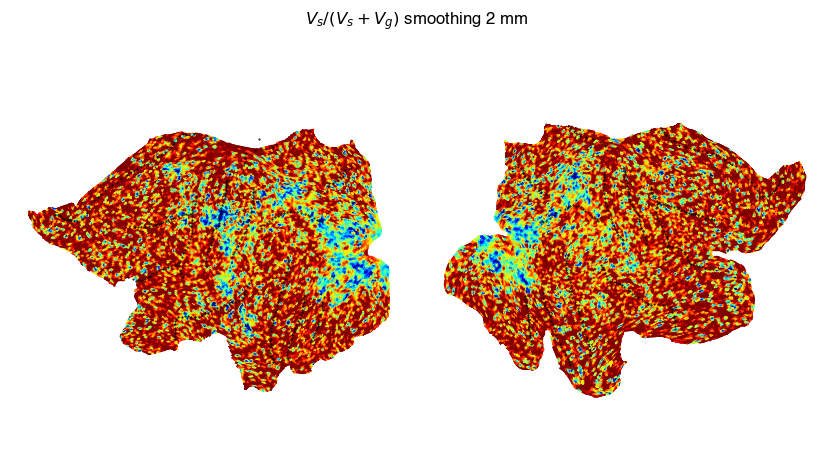

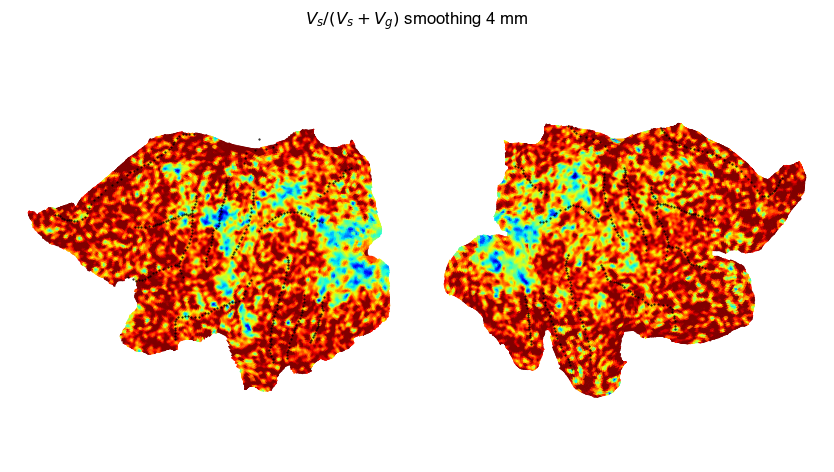

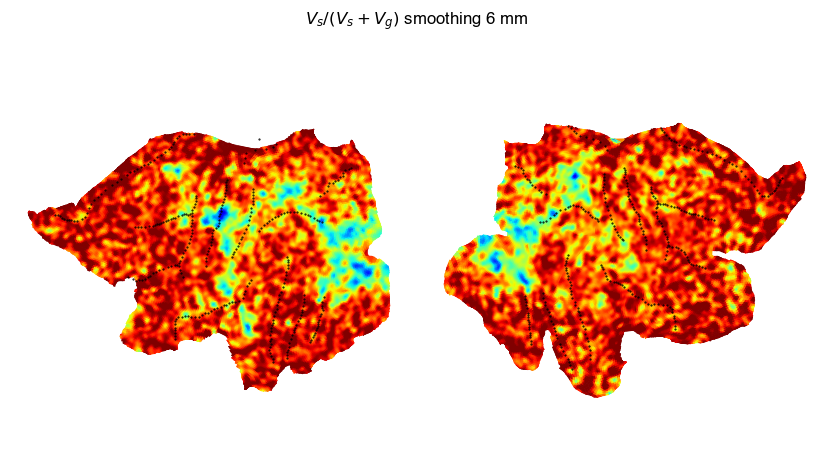

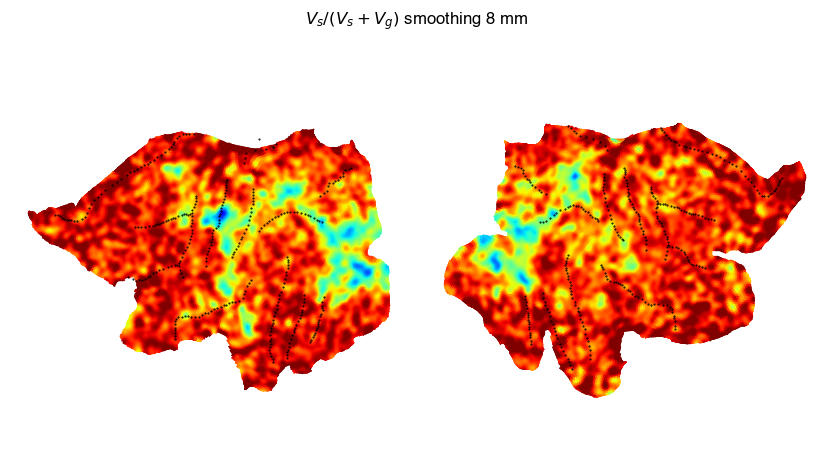

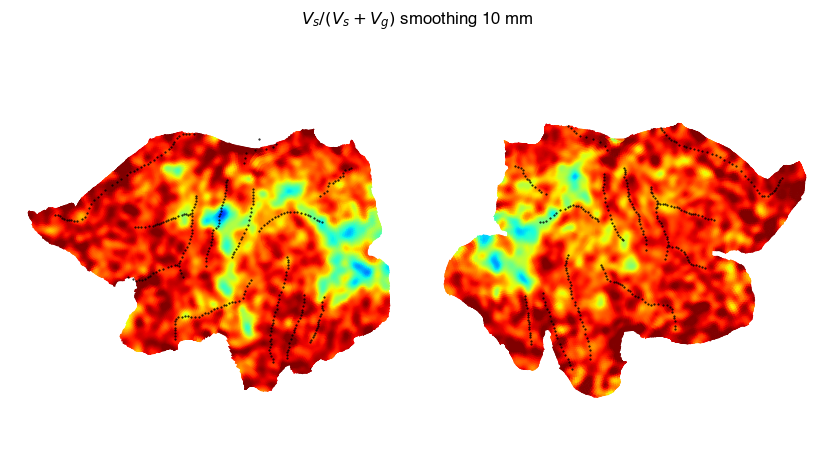

In [12]:
X_unsmoothed = voxel_wise_cortex.reshape(1, -1)
X_unsmoothed[np.isnan(X_unsmoothed)] = 0 

cifti_subj_cond = atlas.data_to_cifti(X_unsmoothed)
cifti_file_name = os.path.join(temp_smoothing_path, f'cifti_unsmoothed_vs_gs_{dataset_name}.dscalar.nii')
nib.save(cifti_subj_cond, cifti_file_name)
output_smoothed[f'smoothed_0_mm'] = X_unsmoothed

for smoothing_kernel in smoothing_kernels:  
    cifti_smoothed_file_name = os.path.join(temp_smoothing_path, f'cifti_smoothed_{smoothing_kernel}mm_vs_gs_{dataset_name}.dscalar.nii')
    wb_cmd = f'wb_command -cifti-smoothing {cifti_file_name} {smoothing_kernel} {smoothing_kernel} COLUMN {cifti_smoothed_file_name} -left-surface {flat_surf_L} -right-surface {flat_surf_R} -fwhm'
    subprocess.run(wb_cmd, shell=True)

    cifti_smoothed = nib.load(cifti_smoothed_file_name)
    X_smoothed = atlas.cifti_to_data(cifti_smoothed)

    X_smoothed[np.isnan(X_smoothed)] = 0 

    output_smoothed[f'smoothed_{smoothing_kernel}_mm'] = X_smoothed

    plt.figure().set_figwidth(full_width) 
    plt.subplot(1, 2, 1)
    flatmap_real_vals(X_smoothed, hemi='L', cscale=[0, 1], cmap='jet') 
    plt.subplot(1, 2, 2)
    flatmap_real_vals(X_smoothed, hemi='R', cscale=[0, 1], cmap='jet', colorbar=False)  
    plt.suptitle(f'$V_s/(V_s+V_g)$ smoothing {smoothing_kernel} mm', fontsize=12)
    plt.tight_layout()

    PS_variance = os.path.join(resultsPath, dataset_name, f'{dataset_name}_flatmap_vs_gs_smoothed_{smoothing_kernel}mm.jpg')
    if os.path.exists(PS_variance):
        os.remove(PS_variance)
    plt.savefig(PS_variance, format='jpg', dpi=500)

with open(PKL_smoothed, 'wb') as pf:
    pickle.dump(output_smoothed, pf) 

## vs/(vs + vg) in whole cortex, PFC, visual, somatosensory and parietal regions

In [13]:
ROIs = ['PFC', 'parietal', 'visual', 'somatosensory'] 
n_rois = len(ROIs)
props = [] 

for roiI in np.arange(n_rois):
    result = np.array(output[ROIs[roiI]]['global'])  
    prop = np.divide(result[:,1], result[:,0]+result[:,1])
    props.append(prop) 

props = np.array(props)     # n_rois x n_bootstraps, each element is vs/(vs+vg) 

In [14]:
props_mean = props[:, 0] 
props_std = np.std(props[:, 1:]) 

PFC and parietal: 0.02
PFC and visual: 0.0
PFC and somatosensory: 0.0


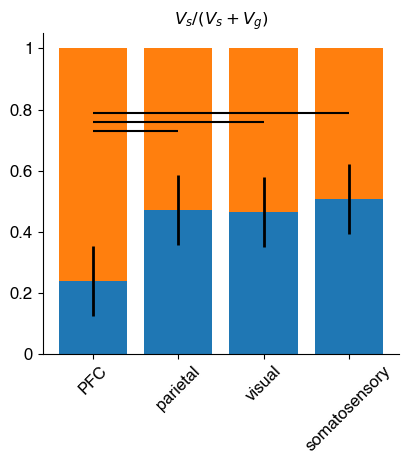

In [15]:
fig, ax = plt.subplots(1, 1)
fig.set_figwidth(half_width) 

# sns.barplot(props_mean, color='tab:orange', ax=ax)            # bar plot for the mean of vs 
# sns.barplot(props_mean - 1, color='tab:blue', ax=ax)          # bar plot for the mean of vg
bottoms = np.zeros(n_rois) 
plt.bar(np.arange(n_rois), 1 - props_mean, label='group', bottom=bottoms, color='tab:blue') 
bottoms += 1 - props_mean
plt.bar(np.arange(n_rois), props_mean, label='individual', bottom=bottoms, color='tab:orange')  
# plt.legend(frameon=False) 

ax.errorbar(np.arange(n_rois), 1 - props_mean, yerr=props_std, linestyle='None', color='k', linewidth=2) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(n_rois), labels=ROIs, fontsize=12, rotation=45)
ax.set_title('$V_s/(V_s + V_g)$', fontsize=12) 
ax.yaxis.set_major_formatter(lambda x, pos: f'{abs(x):g}')

# bootstrap tests between PFC and other ROIs 
significance_level = 0.05 
for j in np.arange(1, n_rois):
    pvalue = np.sum(props[0, 1:] < props[j, 1:]) / len(props[0, 1:]) 
    if pvalue < significance_level:
        ax.hlines(y = 0.7+j*0.03, xmin=0, xmax=j, colors='0')

    print(f'PFC and {ROIs[j]}: {pvalue}') 

plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, dataset_name, f'variance_decomposition_bar_plot.jpg')
plt.savefig(JPG_fig, format='jpg', dpi=500) 

In PFC, group variance accounts for 24% out of total explainable variance, while individual variance accounts for 76%. 

## Integrating the $V_s/(V_s + V_g)$ map across datasets 

In [16]:
datasets = ['MDTB', 'Language', 'Demand', 'Nishimoto', 'HCPur100', 'IBC']
maps_across_datasets = [] 
avg_map_path = os.path.join(mainResultsPath, 'START_A2_gse_decomposition')
smoothing = '4_mm'

for dataset_name in datasets:
    PKL_output = os.path.join(avg_map_path, dataset_name, 'temp', f'smoothed_vs_gs_{dataset_name}.pkl') 
    with open(PKL_output, 'rb') as pf:
        output = pickle.load(pf)
    
    voxel_wise_cortex = output[f'smoothed_{smoothing}']   # columns in the order: vg, vs, ve 
    maps_across_datasets.append(voxel_wise_cortex)

In [17]:
maps_across_datasets = np.array(maps_across_datasets)
maps_across_datasets[maps_across_datasets>threshold_max] = np.nan 
maps_across_datasets[maps_across_datasets<threshold_min] = np.nan 
maps_across_datasets = np.nanmean(maps_across_datasets, axis=0)

In [18]:
print(np.nanmin(maps_across_datasets))
print(np.nanmax(maps_across_datasets))

0.0
1.0779269735018413


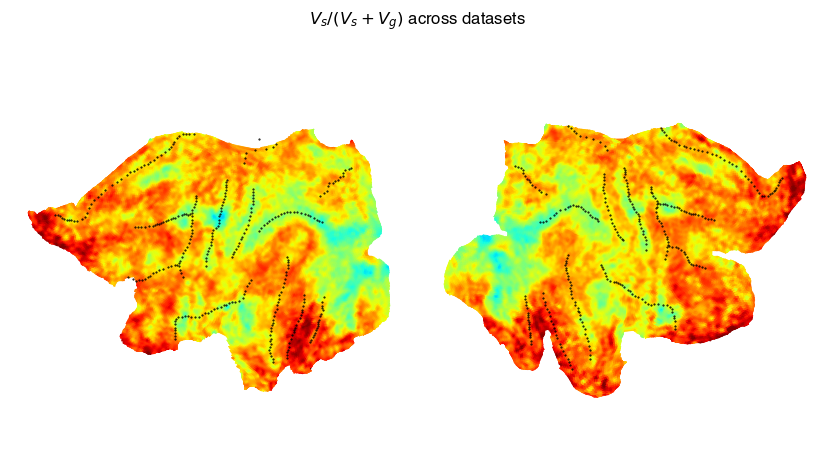

In [19]:
plt.figure().set_figwidth(full_width) 
plt.subplot(1, 2, 1)
flatmap_real_vals(maps_across_datasets, hemi='L', cscale=[0, 1], cmap='jet') 
plt.subplot(1, 2, 2)
flatmap_real_vals(maps_across_datasets, hemi='R', cscale=[0, 1], cmap='jet', colorbar=False)  
plt.suptitle(f'$V_s/(V_s+V_g)$ across datasets', fontsize=12)
plt.tight_layout()

PS_variance = os.path.join(avg_map_path, f'across_datasets_flatmap_vs_gs_{smoothing}.jpg')
if os.path.exists(PS_variance):
    os.remove(PS_variance)
plt.savefig(PS_variance, format='jpg', dpi=500)

## inference for the bar plot
### mixed linear model, using ROIs and datasets as 2 levels

In [20]:
data = {}
data['y'] = []
data['ROI'] = []
data['dataset'] = []

for roiI, roi in enumerate(ROIs):        
    for dataset_name in datasets:
        PKL_output = os.path.join(resultsPath, dataset_name, f'{dataset_name}_output.pkl') 
        with open(PKL_output, 'rb') as pf:
            output = pickle.load(pf) 
        
        result = np.array(output[roi]['subject_wise'])          # subjects x 3 
        prop = np.divide(result[:,1], result[:,0]+result[:,1])  # vs/(vs+vg)

        n_subjects = len(prop)

        data['y'].extend(prop)
        data['ROI'].extend([roi] * n_subjects) 
        data['dataset'].extend([dataset_name] * n_subjects)  

In [21]:
data_pd = pd.DataFrame(data=data) 
data_pd 

,y,ROI,dataset
0,0.747420,PFC,MDTB
1,0.826332,PFC,MDTB
2,0.590603,PFC,MDTB
3,0.772072,PFC,MDTB
4,0.692096,PFC,MDTB
...,...,...,...
579,0.603360,somatosensory,IBC
580,0.503799,somatosensory,IBC
581,0.559391,somatosensory,IBC
582,-0.315740,somatosensory,IBC


In [22]:
res = data_pd.groupby('ROI')['y'].agg(['mean', 'sem']) 
res 

,mean,sem
ROI,,
PFC,0.637019,0.033999
parietal,0.483628,0.014197
somatosensory,0.434752,0.059651
visual,0.408303,0.013575


In [23]:
res['mean'].to_numpy()

array([0.63701909, 0.48362797, 0.43475176, 0.40830289])

PFC and parietal: 4.1405072773922855e-05
PFC and visual: 1.4821333882789222e-09
PFC and somatosensory: 0.0034806575493946715


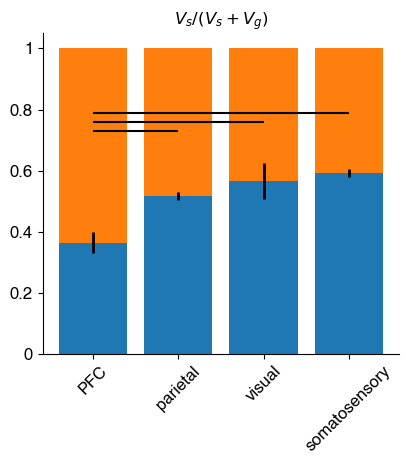

In [24]:
fig, ax = plt.subplots(1, 1)
fig.set_figwidth(half_width) 

bottoms = np.zeros(n_rois) 
plt.bar(np.arange(n_rois), 1 - res['mean'].to_numpy(), label='group', bottom=bottoms, color='tab:blue') 
bottoms += 1 - res['mean'].to_numpy()
plt.bar(np.arange(n_rois), res['mean'].to_numpy(), label='individual', bottom=bottoms, color='tab:orange')  

ax.errorbar(np.arange(n_rois), 1 - res['mean'].to_numpy(), yerr=res['sem'].to_numpy(), linestyle='None', color='k', linewidth=2) 

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(n_rois), labels=ROIs, fontsize=12, rotation=45)
ax.set_title('$V_s/(V_s + V_g)$', fontsize=12) 
ax.yaxis.set_major_formatter(lambda x, pos: f'{abs(x):g}')

# bootstrap tests between PFC and other ROIs 
significance_level = 0.05 
for j in np.arange(1, n_rois):
    ttest_result = ttest_ind(data_pd[data_pd['ROI']=='PFC']['y'], data_pd[data_pd['ROI']==ROIs[j]]['y'])
    pvalue = ttest_result.pvalue 
    if pvalue < significance_level:
        ax.hlines(y = 0.7+j*0.03, xmin=0, xmax=j, colors='0')

    print(f'PFC and {ROIs[j]}: {pvalue}') 

plt.tight_layout() 

JPG_fig = os.path.join(resultsPath, f'variance_decomposition_bar_plot.jpg')
plt.savefig(JPG_fig, format='jpg', dpi=500) 

In [25]:
model = smf.mixedlm('y ~ ROI', data, groups=data['dataset'])
result = model.fit()
result.summary()

/opt/anaconda3/envs/pfc_parcellation/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


<class 'statsmodels.iolib.summary2.Summary'>
"""
             Mixed Linear Model Regression Results
===============================================================
Model:                MixedLM   Dependent Variable:   y        
No. Observations:     584       Method:               REML     
No. Groups:           6         Scale:                0.1808   
Min. group size:      24        Log-Likelihood:       -340.1468
Max. group size:      200       Converged:            Yes      
Mean group size:      97.3                                     
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.672    0.049 13.608 0.000  0.575  0.769
ROI[T.parietal]      -0.153    0.050 -3.083 0.002 -0.251 -0.056
ROI[T.somatosensory] -0.202    0.050 -4.065 0.000 -0.300 -0.105
ROI[T.visual]        -0.229    0.050 -4.596 0.000 -0.326 -0.131
Group Var             0.006    0.012                           
===============================================================

"""